# Plot Layer 15 Hits for a Selected Event

This notebook uses Event 74, filters the hit table to `layer == 15`, and draws a 2D `phi` versus `tbin` map of the selected hits colored by ADC.


## Imports and file paths

The notebook expects `event74_hits.csv` to be in the same directory as the notebook.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path('../csv/event74_hits.csv')
LAYER_TO_PLOT = 15

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Missing input CSV: {CSV_PATH}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Load the CSV

Reading the file once into a DataFrame makes it easy to reuse for different event numbers without reparsing the CSV every time.


In [2]:
hits = pd.read_csv(CSV_PATH)
hits["event"] = pd.to_numeric(hits["event"], errors="coerce").astype("Int64")
hits["layer"] = pd.to_numeric(hits["layer"], errors="coerce")
hits["adc"] = pd.to_numeric(hits["adc"], errors="coerce")

print(f"Loaded {len(hits):,} rows from {CSV_PATH.name}")
print("Available events (first 10):", sorted(hits["event"].dropna().unique())[:10])
print("Layer range:", int(hits["layer"].min()), "to", int(hits["layer"].max()))


Loaded 431,640 rows from event74_hits.csv
Available events (first 10): [np.int64(74)]
Layer range: 3 to 56


## Choose an event number

Run the next cell and enter the event number you want to inspect.


In [3]:
# This dataset contains Event 74, so use that event directly.
event_number = 74
print("Selected event:", event_number)


Selected event: 74


## Filter to the requested event and layer 15


In [4]:
layer_hits = hits[(hits["event"] == event_number) & (hits["layer"] == LAYER_TO_PLOT)].copy()
print(f"Found {len(layer_hits):,} hits for event {event_number} in layer {LAYER_TO_PLOT}")
layer_hits.head()


Found 8,018 hits for event 74 in layer 15


,event,layer,phi,tbin,adc,zelem,x,y,z,plot_x,plot_y,plot_z
71832,74,15,2.86686,393.0,101,0,-34.6752,9.77359,166.679,393.0,-14.4375,4.06936
71833,74,15,2.86686,394.0,109,0,-34.6752,9.77359,167.102,394.0,-14.4375,4.06936
71834,74,15,2.86686,395.0,65,0,-34.6752,9.77359,167.526,395.0,-14.4375,4.06936
71835,74,15,2.86686,396.0,253,0,-34.6752,9.77359,167.949,396.0,-14.4375,4.06936
71836,74,15,2.86686,397.0,398,0,-34.6752,9.77359,168.373,397.0,-14.4375,4.06936


## Plot the layer-15 hit distribution

The plot uses `phi` on the horizontal axis and `tbin` on the vertical axis. ADC is shown as the color scale so large-energy hits are easy to spot.


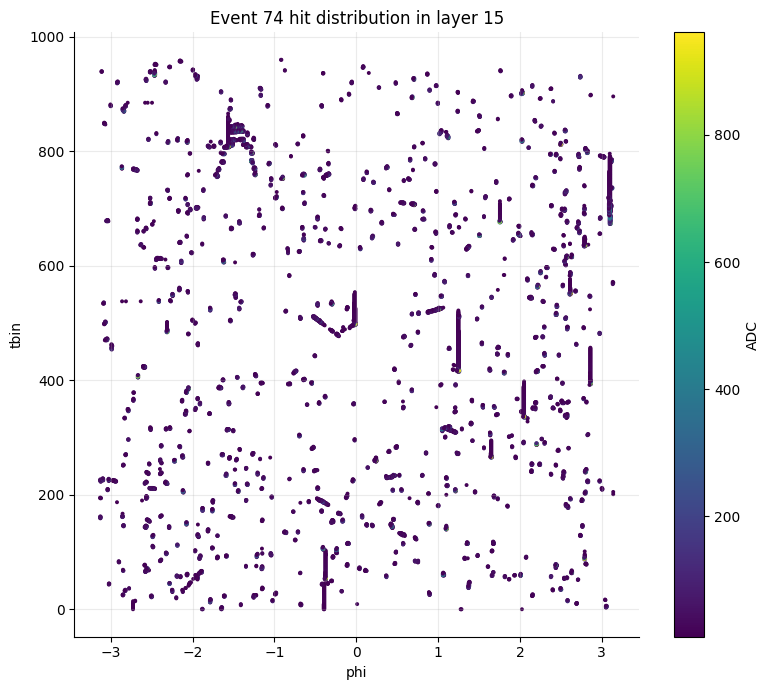

In [5]:
if layer_hits.empty:
    print(f"No layer {LAYER_TO_PLOT} hits were found for event {event_number}.")
else:
    fig, ax = plt.subplots()
    scatter = ax.scatter(
        layer_hits["phi"],
        layer_hits["tbin"],
        c=layer_hits["adc"],
        cmap="viridis",
        s=8,
        linewidths=0,
    )
    ax.set_title(f"Event {event_number} hit distribution in layer {LAYER_TO_PLOT}")
    ax.set_xlabel("phi")
    ax.set_ylabel("tbin")
    fig.colorbar(scatter, ax=ax, label="ADC")
    fig.tight_layout()
    plt.show()


## Zoomed view of the layer-15 hit distribution

This view focuses on the window `0 < phi < 1` and `600 < tbin < 800` so dense structure in that region is easier to inspect.


Found 245 hits in the zoom window


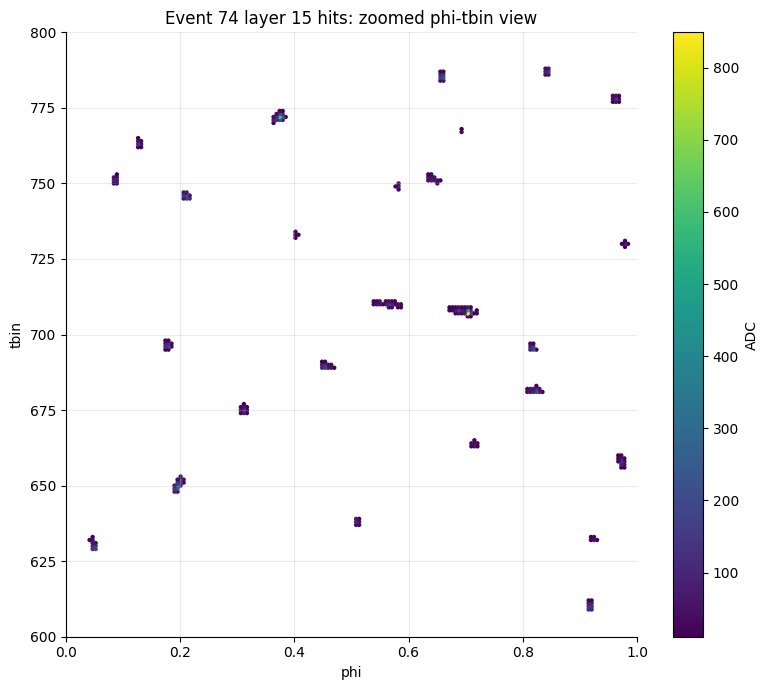

In [6]:
zoom_hits = layer_hits[(layer_hits["phi"] > 0) & (layer_hits["phi"] < 1) & (layer_hits["tbin"] > 600) & (layer_hits["tbin"] < 800)].copy()
print(f"Found {len(zoom_hits):,} hits in the zoom window")

if zoom_hits.empty:
    print("No hits were found in the requested zoom range.")
else:
    fig, ax = plt.subplots()
    scatter = ax.scatter(
        zoom_hits["phi"],
        zoom_hits["tbin"],
        c=zoom_hits["adc"],
        cmap="viridis",
        s=10,
        linewidths=0,
    )
    ax.set_title(f"Event {event_number} layer {LAYER_TO_PLOT} hits: zoomed phi-tbin view")
    ax.set_xlabel("phi")
    ax.set_ylabel("tbin")
    ax.set_xlim(0, 1)
    ax.set_ylim(600, 800)
    fig.colorbar(scatter, ax=ax, label="ADC")
    fig.tight_layout()
    plt.show()


## Zoomed comparison for layers 10-17

This panel compares the same zoom window across layers 10 through 17 in a `2 x 4` layout.


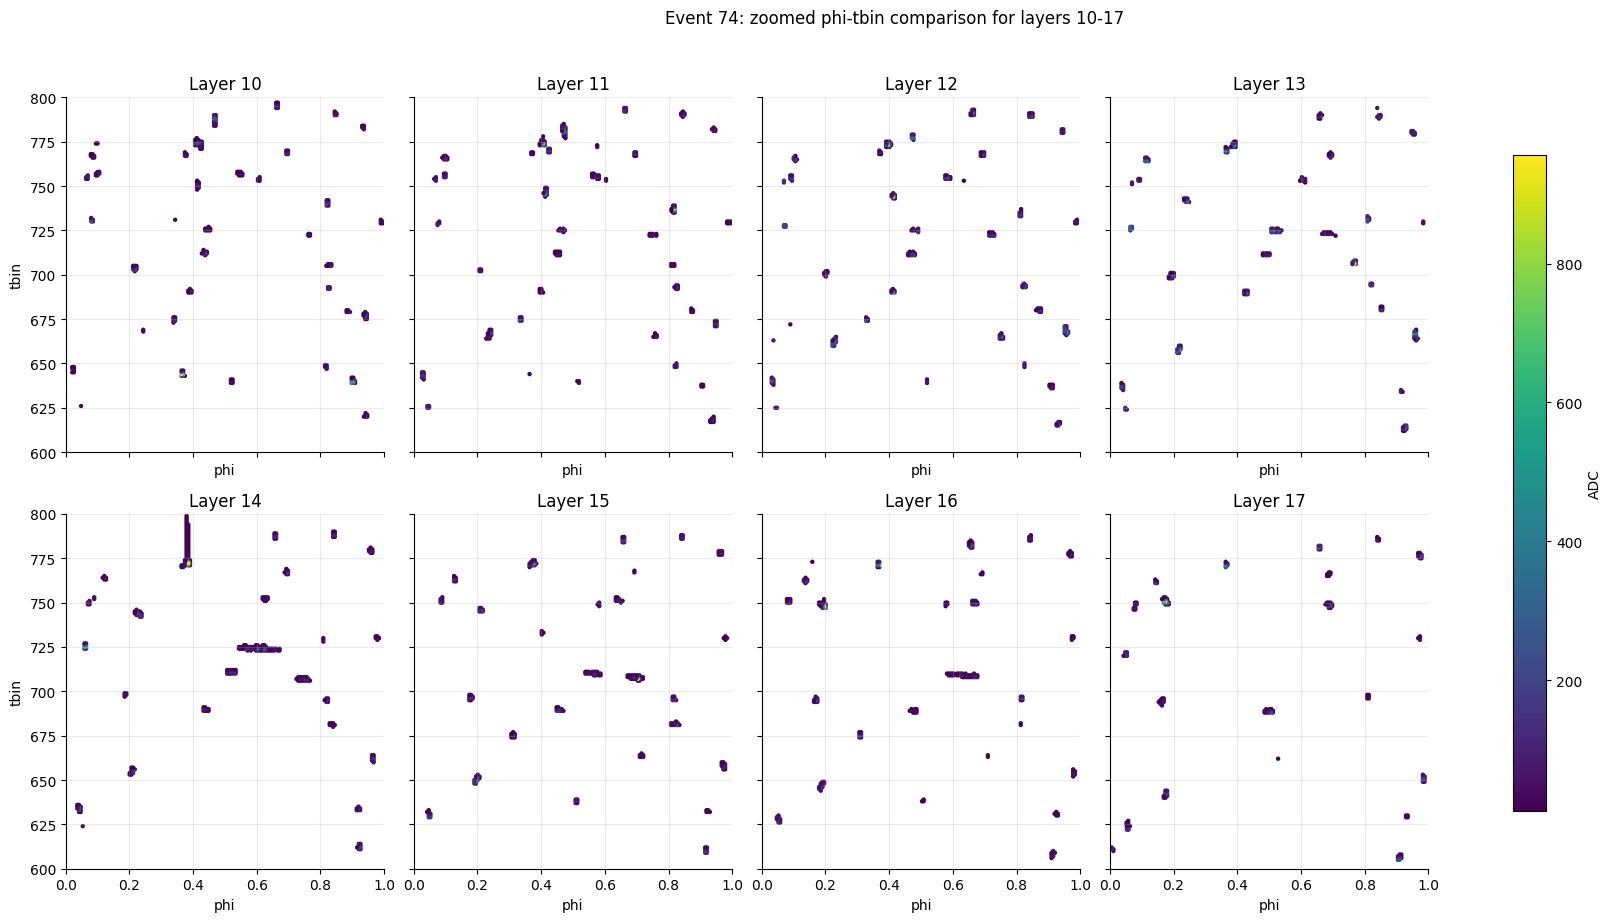

In [7]:
layers_to_compare = list(range(10, 18))
phi_min, phi_max = 0, 1
tbin_min, tbin_max = 600, 800

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
axes = axes.ravel()
scatter = None

for ax, layer_value in zip(axes, layers_to_compare):
    layer_zoom_hits = hits[(hits["event"] == event_number) & (hits["layer"] == layer_value)].copy()
    layer_zoom_hits = layer_zoom_hits[(layer_zoom_hits["phi"] > phi_min) & (layer_zoom_hits["phi"] < phi_max) & (layer_zoom_hits["tbin"] > tbin_min) & (layer_zoom_hits["tbin"] < tbin_max)]

    if layer_zoom_hits.empty:
        ax.text(0.5, 0.5, "No hits", ha="center", va="center", transform=ax.transAxes)
    else:
        scatter = ax.scatter(
            layer_zoom_hits["phi"],
            layer_zoom_hits["tbin"],
            c=layer_zoom_hits["adc"],
            cmap="viridis",
            s=10,
            linewidths=0,
        )

    ax.set_title(f"Layer {layer_value}")
    ax.set_xlim(phi_min, phi_max)
    ax.set_ylim(tbin_min, tbin_max)
    ax.set_xlabel("phi")

for ax in axes[::4]:
    ax.set_ylabel("tbin")

fig.suptitle(f"Event {event_number}: zoomed phi-tbin comparison for layers 10-17", y=1.02)
fig.tight_layout()

if scatter is not None:
    fig.colorbar(scatter, ax=axes, label="ADC", shrink=0.85)

plt.show()


## Optional: save the current plot


In [14]:
if not layer_hits.empty:
    output_path = Path(f"event{event_number}_layer{LAYER_TO_PLOT}_hits_phi_tbin.png")
    fig, ax = plt.subplots()
    scatter = ax.scatter(
        layer_hits["phi"],
        layer_hits["tbin"],
        c=layer_hits["adc"],
        cmap="viridis",
        s=8,
        linewidths=0,
    )
    ax.set_title(f"Event {event_number} hit distribution in layer {LAYER_TO_PLOT}")
    ax.set_xlabel("phi")
    ax.set_ylabel("tbin")
    fig.colorbar(scatter, ax=ax, label="ADC")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {output_path}")


Saved event74_layer15_hits_phi_tbin.png
